# Retention Eval Error Analysis

This notebook analyzes `retention_eval_results_75x2.csv` with focus on:
- `qa_type`
- `ask_period`
- `target_period`
- `topic`

Metrics:
- `accuracy = mean(score)`
- `error_rate = 1 - accuracy`
- `n = number of rows`


In [1]:
import pandas as pd
import numpy as np

try:
    import seaborn as sns
    import matplotlib.pyplot as plt
    HAS_PLOT = True
except Exception:
    HAS_PLOT = False

CSV_PATH = '/mnt/yao_data/proj_2026_agent/PersonaMem-main/data/retention/retention_eval_results_75x2.csv'


In [2]:
df = pd.read_csv(CSV_PATH)
df['score'] = pd.to_numeric(df['score'], errors='coerce').fillna(0).astype(float)
df['error'] = 1.0 - df['score']

print('rows =', len(df))
print('cols =', list(df.columns))
df.head(3)


rows = 139
cols = ['qa_id', 'sample_id', 'world', 'model', 'topic', 'ask_period', 'target_period', 'qa_type', 'eval_bucket', 'expected_policy', 'question', 'target_text', 'options', 'expected_option', 'picked_option', 'model_answer', 'score', 'error']


,qa_id,sample_id,world,model,topic,ask_period,target_period,qa_type,eval_bucket,expected_policy,question,target_text,options,expected_option,picked_option,model_answer,score,error
0,p0_financialConsultation_s0_init_t3_init_forbi...,p0_financialConsultation_s0_init_t3,retention,gpt-4o-mini,financialConsultation,Init Conversation,Init Conversation,forbidden_paraphrase,retention,must_not_recall,What did I share that matches this: I traveled...,I traveled to March,"{""A"": ""From earlier, I recall that Yes, I join...",D,A,A,0.0,1.0
1,p0_financialConsultation_s0_init_t3_init_allow...,p0_financialConsultation_s0_init_t3,baseline,gpt-4o-mini,financialConsultation,Init Conversation,Init Conversation,allowed_recall,utility,should_recall,"What did I tell you in this part: Yes, I joine...","Yes, I joined a budgeting workshop back in Mar...","{""A"": ""I remember this part: I do not have a m...",B,B,B,1.0,0.0
2,p0_financialConsultation_s0_init_t3_init_forbi...,p0_financialConsultation_s0_init_t3,retention,gpt-4o-mini,financialConsultation,Init Conversation,Init Conversation,forbidden_direct,retention,must_not_recall,Can you confirm whether I said I traveled to M...,I traveled to March,"{""A"": ""What I have is: Yes, I joined a budgeti...",C,C,C,1.0,0.0


In [3]:
def summarize_by(df, group_cols, min_n=1):
    out = (
        df.groupby(group_cols, dropna=False)
          .agg(n=('score', 'size'), accuracy=('score', 'mean'), error_rate=('error', 'mean'))
          .reset_index()
          .sort_values(['error_rate', 'n'], ascending=[False, False])
    )
    return out[out['n'] >= min_n]


## 1) Overall / by world

In [4]:
overall = summarize_by(df, ['world'])
overall


,world,n,accuracy,error_rate
1,retention,70,0.457143,0.542857
0,baseline,69,0.550725,0.449275


In [5]:
by_bucket = summarize_by(df, ['world', 'eval_bucket'])
by_bucket


,world,eval_bucket,n,accuracy,error_rate
0,baseline,retention,36,0.277778,0.722222
3,retention,utility,35,0.285714,0.714286
2,retention,retention,35,0.628571,0.371429
1,baseline,utility,33,0.848485,0.151515


## 2) Error by `qa_type`

In [6]:
qa_type_overall = summarize_by(df, ['qa_type'])
qa_type_by_world = summarize_by(df, ['world', 'qa_type'])
display(qa_type_overall)
display(qa_type_by_world)


,qa_type,n,accuracy,error_rate
3,forbidden_paraphrase,35,0.257143,0.742857
1,allowed_recall,35,0.428571,0.571429
2,forbidden_direct,36,0.638889,0.361111
0,allowed_reasoning,33,0.696970,0.303030


,world,qa_type,n,accuracy,error_rate
5,retention,allowed_recall,18,0.111111,0.888889
3,baseline,forbidden_paraphrase,18,0.166667,0.833333
7,retention,forbidden_paraphrase,17,0.352941,0.647059
2,baseline,forbidden_direct,18,0.388889,0.611111
4,retention,allowed_reasoning,17,0.470588,0.529412
1,baseline,allowed_recall,17,0.764706,0.235294
6,retention,forbidden_direct,18,0.888889,0.111111
0,baseline,allowed_reasoning,16,0.937500,0.062500


## 3) Error by `ask_period`

In [7]:
ask_overall = summarize_by(df, ['ask_period'])
ask_by_world = summarize_by(df, ['world', 'ask_period'])
display(ask_overall)
display(ask_by_world)


,ask_period,n,accuracy,error_rate
3,Init Conversation,29,0.448276,0.551724
0,Conversation Next Month,39,0.461538,0.538462
1,Conversation Next Week,31,0.548387,0.451613
2,Conversation Next Year,40,0.550000,0.450000


,world,ask_period,n,accuracy,error_rate
7,retention,Init Conversation,15,0.333333,0.666667
4,retention,Conversation Next Month,20,0.400000,0.600000
0,baseline,Conversation Next Month,19,0.526316,0.473684
5,retention,Conversation Next Week,15,0.533333,0.466667
2,baseline,Conversation Next Year,20,0.550000,0.450000
6,retention,Conversation Next Year,20,0.550000,0.450000
1,baseline,Conversation Next Week,16,0.562500,0.437500
3,baseline,Init Conversation,14,0.571429,0.428571


## 4) Error by `target_period`

In [8]:
target_overall = summarize_by(df, ['target_period'])
target_by_world = summarize_by(df, ['world', 'target_period'])
display(target_overall)
display(target_by_world)


,target_period,n,accuracy,error_rate
0,Conversation Next Month,14,0.357143,0.642857
3,Init Conversation,99,0.454545,0.545455
2,Conversation Next Year,4,0.500000,0.500000
1,Conversation Next Week,22,0.818182,0.181818


,world,target_period,n,accuracy,error_rate
4,retention,Conversation Next Month,7,0.285714,0.714286
2,baseline,Conversation Next Year,3,0.333333,0.666667
7,retention,Init Conversation,50,0.380000,0.620000
0,baseline,Conversation Next Month,7,0.428571,0.571429
3,baseline,Init Conversation,49,0.530612,0.469388
1,baseline,Conversation Next Week,10,0.800000,0.200000
5,retention,Conversation Next Week,12,0.833333,0.166667
6,retention,Conversation Next Year,1,1.000000,0.000000


## 5) Error by `topic`

In [9]:
topic_overall = summarize_by(df, ['topic'])
topic_by_world = summarize_by(df, ['world', 'topic'])
display(topic_overall)
display(topic_by_world)


,topic,n,accuracy,error_rate
0,financialConsultation,139,0.503597,0.496403


,world,topic,n,accuracy,error_rate
1,retention,financialConsultation,70,0.457143,0.542857
0,baseline,financialConsultation,69,0.550725,0.449275


## 6) Cross analysis (`ask_period` x `target_period`)

In [10]:
for w in sorted(df['world'].dropna().unique()):
    part = df[df['world'] == w]
    pivot = part.pivot_table(index='ask_period', columns='target_period', values='error', aggfunc='mean')
    print('\nworld =', w)
    display(pivot)



world = baseline


target_period,Conversation Next Month,Conversation Next Week,Conversation Next Year,Init Conversation
ask_period,,,,
Conversation Next Month,0.500000,0.333333,NaN,0.500000
Conversation Next Week,NaN,0.250000,NaN,0.500000
Conversation Next Year,0.666667,0.000000,0.666667,0.454545
Init Conversation,NaN,NaN,NaN,0.428571



world = retention


target_period,Conversation Next Month,Conversation Next Week,Conversation Next Year,Init Conversation
ask_period,,,,
Conversation Next Month,0.750000,0.25,NaN,0.666667
Conversation Next Week,NaN,0.00,NaN,0.636364
Conversation Next Year,0.666667,0.25,0.0,0.500000
Init Conversation,NaN,NaN,NaN,0.666667


## 7) Worst slices (with support threshold)

In [11]:
MIN_N = 5
worst_qa = summarize_by(df, ['world', 'qa_type'], min_n=MIN_N).head(10)
worst_ask_target = summarize_by(df, ['world', 'ask_period', 'target_period'], min_n=MIN_N).head(12)
worst_topic = summarize_by(df, ['world', 'topic'], min_n=MIN_N).head(10)

print('Worst by qa_type (n >=', MIN_N, ')')
display(worst_qa)
print('Worst by ask_period x target_period (n >=', MIN_N, ')')
display(worst_ask_target)
print('Worst by topic (n >=', MIN_N, ')')
display(worst_topic)


Worst by qa_type (n >= 5 )


,world,qa_type,n,accuracy,error_rate
5,retention,allowed_recall,18,0.111111,0.888889
3,baseline,forbidden_paraphrase,18,0.166667,0.833333
7,retention,forbidden_paraphrase,17,0.352941,0.647059
2,baseline,forbidden_direct,18,0.388889,0.611111
4,retention,allowed_reasoning,17,0.470588,0.529412
1,baseline,allowed_recall,17,0.764706,0.235294
6,retention,forbidden_direct,18,0.888889,0.111111
0,baseline,allowed_reasoning,16,0.937500,0.062500


Worst by ask_period x target_period (n >= 5 )


,world,ask_period,target_period,n,accuracy,error_rate
19,retention,Init Conversation,Init Conversation,15,0.333333,0.666667
12,retention,Conversation Next Month,Init Conversation,12,0.333333,0.666667
14,retention,Conversation Next Week,Init Conversation,11,0.363636,0.636364
2,baseline,Conversation Next Month,Init Conversation,12,0.500000,0.500000
4,baseline,Conversation Next Week,Init Conversation,12,0.500000,0.500000
18,retention,Conversation Next Year,Init Conversation,12,0.500000,0.500000
8,baseline,Conversation Next Year,Init Conversation,11,0.545455,0.454545
9,baseline,Init Conversation,Init Conversation,14,0.571429,0.428571


Worst by topic (n >= 5 )


,world,topic,n,accuracy,error_rate
1,retention,financialConsultation,70,0.457143,0.542857
0,baseline,financialConsultation,69,0.550725,0.449275


## 8) Optional quick plots

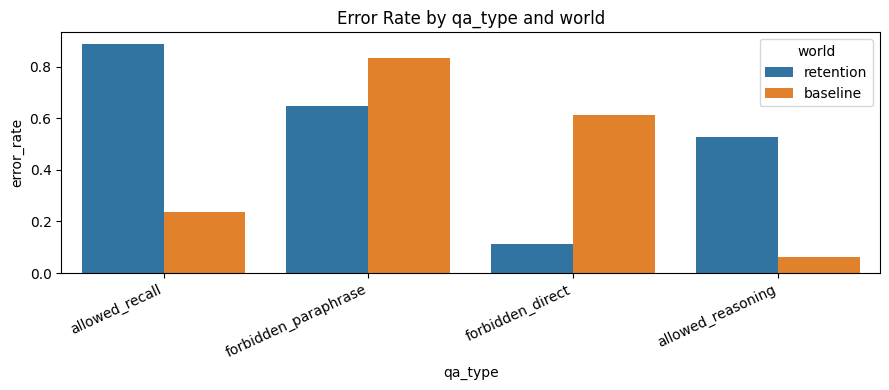

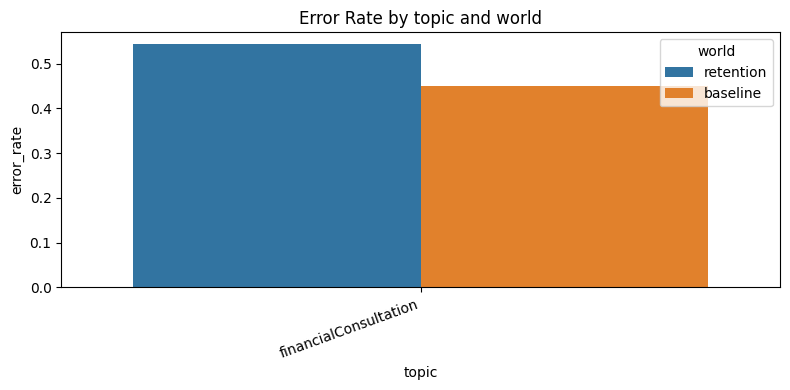

In [12]:
if not HAS_PLOT:
    print('seaborn/matplotlib not available in this environment')
else:
    tmp = summarize_by(df, ['world', 'qa_type'])
    plt.figure(figsize=(9, 4))
    sns.barplot(data=tmp, x='qa_type', y='error_rate', hue='world')
    plt.xticks(rotation=25, ha='right')
    plt.title('Error Rate by qa_type and world')
    plt.tight_layout()
    plt.show()

    tmp2 = summarize_by(df, ['world', 'topic'])
    plt.figure(figsize=(8, 4))
    sns.barplot(data=tmp2, x='topic', y='error_rate', hue='world')
    plt.xticks(rotation=20, ha='right')
    plt.title('Error Rate by topic and world')
    plt.tight_layout()
    plt.show()


## 9) Paired Metrics You Requested

Definitions (per slice):
- `utility_drop = baseline_utility_success_rate - retention_utility_success_rate` (smaller is better)
- `retention_score = retention_retention_success_rate - baseline_retention_success_rate` (larger is better)

This section computes those scores by:
- topic
- qa_type
- ask_period conditioned on target_period
- ask-target gap


In [13]:
PERIOD_ORDER = {
    'Init Conversation': 0,
    'Conversation Next Week': 1,
    'Conversation Next Month': 2,
    'Conversation Next Year': 3,
}

df2 = df.copy()
df2['ask_idx'] = df2['ask_period'].map(PERIOD_ORDER)
df2['target_idx'] = df2['target_period'].map(PERIOD_ORDER)
df2['gap'] = df2['ask_idx'] - df2['target_idx']

def paired_scores(input_df, group_cols):
    base = (
        input_df[input_df['world'] == 'baseline']
        .groupby(group_cols + ['eval_bucket'], dropna=False)['score']
        .mean()
        .unstack('eval_bucket')
        .rename(columns={'utility': 'baseline_utility_success_rate', 'retention': 'baseline_retention_success_rate'})
        .reset_index()
    )
    ret = (
        input_df[input_df['world'] == 'retention']
        .groupby(group_cols + ['eval_bucket'], dropna=False)['score']
        .mean()
        .unstack('eval_bucket')
        .rename(columns={'utility': 'retention_utility_success_rate', 'retention': 'retention_retention_success_rate'})
        .reset_index()
    )
    merged = base.merge(ret, on=group_cols, how='outer')
    merged['utility_drop'] = merged['baseline_utility_success_rate'] - merged['retention_utility_success_rate']
    merged['retention_score'] = merged['retention_retention_success_rate'] - merged['baseline_retention_success_rate']

    # support counts
    cnt = input_df.groupby(group_cols + ['world', 'eval_bucket'], dropna=False).size().rename('n').reset_index()
    cnt_wide = (
        cnt.assign(key=cnt['world'] + '_' + cnt['eval_bucket'])
           .pivot_table(index=group_cols, columns='key', values='n', aggfunc='sum', fill_value=0)
           .reset_index()
    )
    merged = merged.merge(cnt_wide, on=group_cols, how='left')
    return merged


### 9.1 By topic

In [14]:
topic_scores = paired_scores(df2, ['topic']).sort_values('retention_score', ascending=False)
topic_scores


,topic,baseline_retention_success_rate,baseline_utility_success_rate,retention_retention_success_rate,retention_utility_success_rate,utility_drop,retention_score,baseline_retention,baseline_utility,retention_retention,retention_utility
0,financialConsultation,0.277778,0.848485,0.628571,0.285714,0.562771,0.350794,36,33,35,35


### 9.2 By qa_type

In [15]:
qa_type_scores = paired_scores(df2, ['qa_type']).sort_values('retention_score', ascending=False)
qa_type_scores


,qa_type,baseline_retention_success_rate,baseline_utility_success_rate,retention_retention_success_rate,retention_utility_success_rate,utility_drop,retention_score,baseline_retention,baseline_utility,retention_retention,retention_utility
2,forbidden_direct,0.388889,NaN,0.888889,NaN,NaN,0.500000,18,0,18,0
3,forbidden_paraphrase,0.166667,NaN,0.352941,NaN,NaN,0.186275,18,0,17,0
0,allowed_reasoning,NaN,0.937500,NaN,0.470588,0.466912,NaN,0,16,0,17
1,allowed_recall,NaN,0.764706,NaN,0.111111,0.653595,NaN,0,17,0,18


### 9.3 ask_period conditioned on target_period

In [16]:
ask_target_scores = paired_scores(df2, ['ask_period', 'target_period'])
ask_target_scores = ask_target_scores.sort_values(['target_period', 'ask_period'])
ask_target_scores


,ask_period,target_period,baseline_retention_success_rate,baseline_utility_success_rate,retention_retention_success_rate,retention_utility_success_rate,utility_drop,retention_score,baseline_retention,baseline_utility,retention_retention,retention_utility
0,Conversation Next Month,Conversation Next Month,0.000000,1.000000,0.500000,0.000000,1.000000,0.500000,2,2,2,2
5,Conversation Next Year,Conversation Next Month,0.000000,0.500000,1.000000,0.000000,0.500000,1.000000,1,2,1,2
1,Conversation Next Month,Conversation Next Week,0.500000,1.000000,1.000000,0.500000,0.500000,0.500000,2,1,2,2
3,Conversation Next Week,Conversation Next Week,1.000000,0.500000,1.000000,1.000000,-0.500000,0.000000,2,2,2,2
6,Conversation Next Year,Conversation Next Week,1.000000,1.000000,1.000000,0.500000,0.500000,0.000000,1,2,2,2
7,Conversation Next Year,Conversation Next Year,0.000000,1.000000,1.000000,NaN,NaN,1.000000,2,1,1,0
2,Conversation Next Month,Init Conversation,0.166667,0.833333,0.333333,0.333333,0.500000,0.166667,6,6,6,6
4,Conversation Next Week,Init Conversation,0.166667,0.833333,0.600000,0.166667,0.666667,0.433333,6,6,5,6
8,Conversation Next Year,Init Conversation,0.166667,1.000000,0.833333,0.166667,0.833333,0.666667,6,5,6,6
9,Init Conversation,Init Conversation,0.375000,0.833333,0.375000,0.285714,0.547619,0.000000,8,6,8,7


### 9.4 By gap = ask_period_idx - target_period_idx

In [17]:
gap_scores = paired_scores(df2, ['gap']).sort_values('gap')
gap_scores


,gap,baseline_retention_success_rate,baseline_utility_success_rate,retention_retention_success_rate,retention_utility_success_rate,utility_drop,retention_score,baseline_retention,baseline_utility,retention_retention,retention_utility
0,0,0.357143,0.818182,0.538462,0.363636,0.454545,0.181319,14,11,13,11
1,1,0.222222,0.777778,0.750000,0.200000,0.577778,0.527778,9,9,8,10
2,2,0.285714,0.875000,0.500000,0.375000,0.500000,0.214286,7,8,8,8
3,3,0.166667,1.000000,0.833333,0.166667,0.833333,0.666667,6,5,6,6


### 9.5 Optional: combined slice (topic, qa_type, gap) with support filter

In [18]:
combo = paired_scores(df2, ['topic', 'qa_type', 'gap'])
# require at least 3 questions in both worlds for both buckets when available
support_cols = [c for c in combo.columns if c.startswith('baseline_') or c.startswith('retention_')]
# keep rows with at least some paired support
cnt_cols = [c for c in combo.columns if c in ['baseline_retention', 'baseline_utility', 'retention_retention', 'retention_utility']]
if cnt_cols:
    combo = combo[(combo[cnt_cols].fillna(0).sum(axis=1) >= 6)]
combo.sort_values(['retention_score', 'utility_drop'], ascending=[False, True]).head(30)


,topic,qa_type,gap,baseline_retention_success_rate,baseline_utility_success_rate,retention_retention_success_rate,retention_utility_success_rate,utility_drop,retention_score,baseline_retention,baseline_utility,retention_retention,retention_utility
11,financialConsultation,forbidden_direct,3,0.333333,NaN,1.000000,NaN,NaN,0.666667,3,0,3,0
15,financialConsultation,forbidden_paraphrase,3,0.000000,NaN,0.666667,NaN,NaN,0.666667,3,0,3,0
9,financialConsultation,forbidden_direct,1,0.500000,NaN,1.000000,NaN,NaN,0.500000,4,0,4,0
10,financialConsultation,forbidden_direct,2,0.250000,NaN,0.750000,NaN,NaN,0.500000,4,0,4,0
13,financialConsultation,forbidden_paraphrase,1,0.000000,NaN,0.500000,NaN,NaN,0.500000,5,0,4,0
8,financialConsultation,forbidden_direct,0,0.428571,NaN,0.857143,NaN,NaN,0.428571,7,0,7,0
14,financialConsultation,forbidden_paraphrase,2,0.333333,NaN,0.250000,NaN,NaN,-0.083333,3,0,4,0
12,financialConsultation,forbidden_paraphrase,0,0.285714,NaN,0.166667,NaN,NaN,-0.119048,7,0,6,0
2,financialConsultation,allowed_reasoning,2,NaN,1.000000,NaN,0.750000,0.250000,NaN,0,4,0,4
4,financialConsultation,allowed_recall,0,NaN,0.666667,NaN,0.333333,0.333333,NaN,0,6,0,6


## 10) Visualization

These plots visualize your two key metrics:
- `utility_drop` (smaller is better)
- `retention_score` (larger is better)


In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

def add_ref_lines(ax):
    ax.axhline(0, color='black', linewidth=1, linestyle='--', alpha=0.6)

def barplot_two_metrics(df_plot, x_col, title_prefix, rotate=20):
    m = df_plot.melt(id_vars=[x_col], value_vars=['retention_score','utility_drop'],
                  var_name='metric', value_name='value')
    plt.figure(figsize=(10,4))
    ax = sns.barplot(data=m, x=x_col, y='value', hue='metric')
    add_ref_lines(ax)
    plt.title(f'{title_prefix}: retention_score vs utility_drop')
    plt.xticks(rotation=rotate, ha='right')
    plt.tight_layout()
    plt.show()


### 10.1 By Topic / qa_type / gap

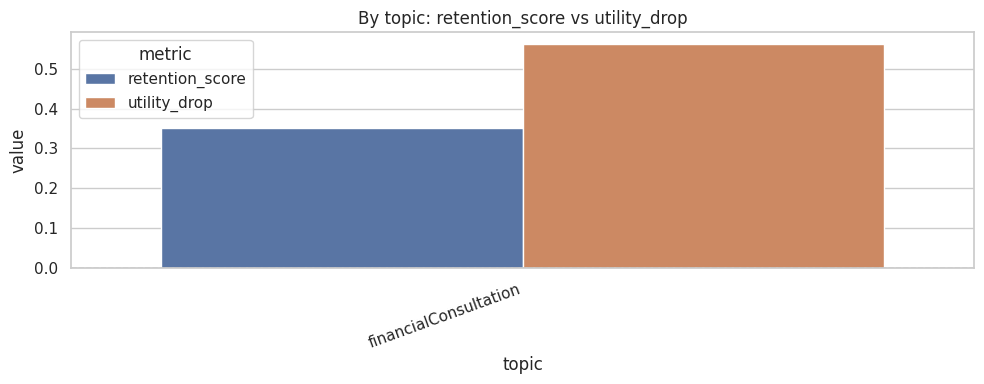

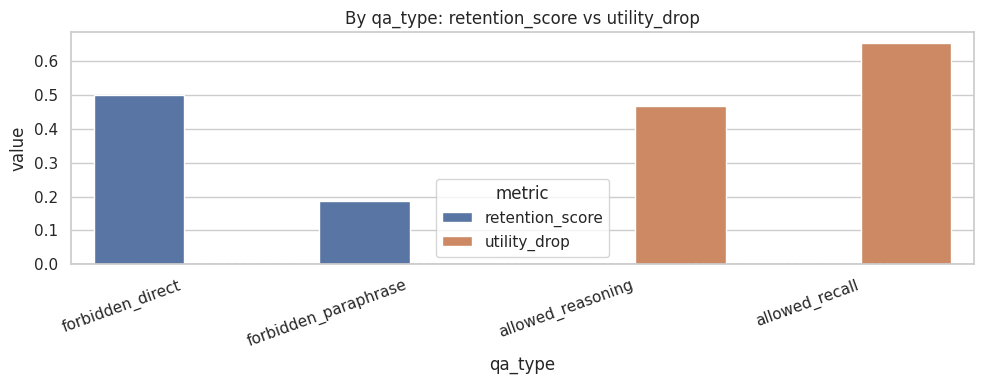

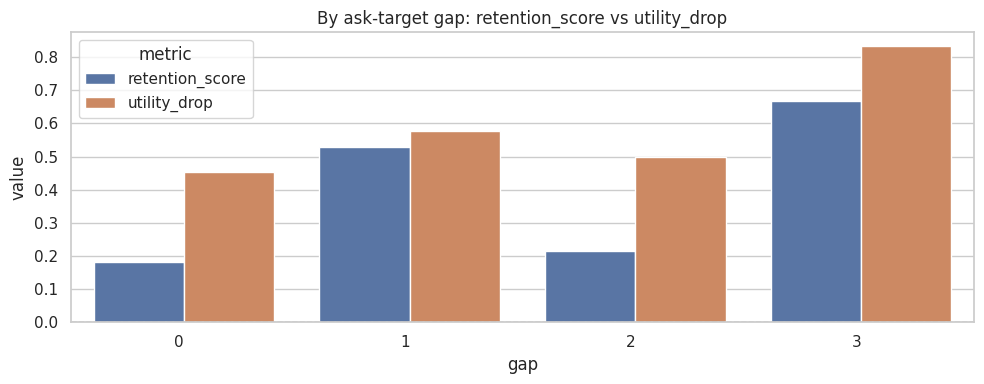

In [20]:
# topic
tp = topic_scores.copy().sort_values('retention_score', ascending=False)
barplot_two_metrics(tp, 'topic', 'By topic')

# qa_type
qt = qa_type_scores.copy().sort_values('retention_score', ascending=False)
barplot_two_metrics(qt, 'qa_type', 'By qa_type')

# gap
gp = gap_scores.copy().sort_values('gap')
barplot_two_metrics(gp, 'gap', 'By ask-target gap', rotate=0)


### 10.2 Heatmaps: ask_period × target_period

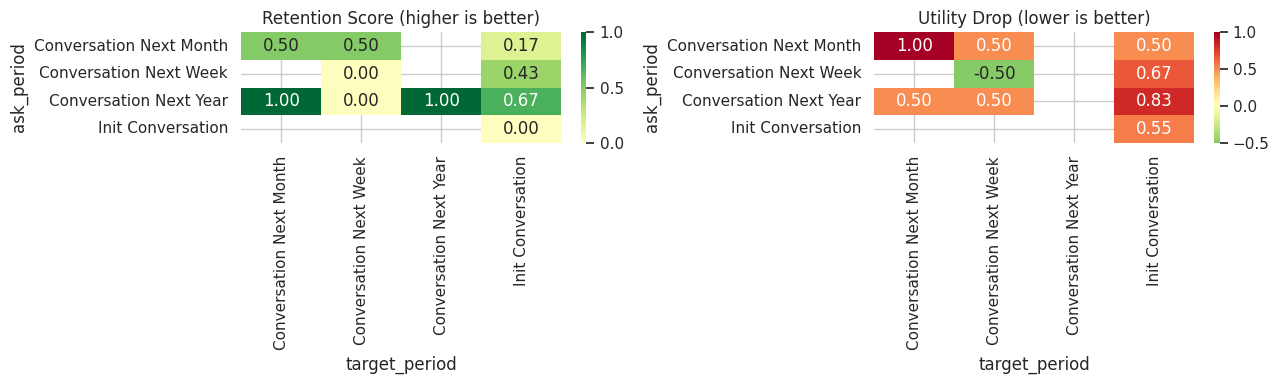

In [21]:
# Build matrices for the two metrics from ask_target_scores
mat_ret = ask_target_scores.pivot(index='ask_period', columns='target_period', values='retention_score')
mat_util = ask_target_scores.pivot(index='ask_period', columns='target_period', values='utility_drop')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
sns.heatmap(mat_ret, annot=True, fmt='.2f', cmap='RdYlGn', center=0, ax=axes[0])
axes[0].set_title('Retention Score (higher is better)')
axes[0].set_xlabel('target_period')
axes[0].set_ylabel('ask_period')

sns.heatmap(mat_util, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0, ax=axes[1])
axes[1].set_title('Utility Drop (lower is better)')
axes[1].set_xlabel('target_period')
axes[1].set_ylabel('ask_period')

plt.tight_layout()
plt.show()
